# Bank Customer Churn Prediction

**Goal:** Predict whether a bank customer will churn (`Exited = 1`) using machine learning.

**Evaluation metric:** ROC-AUC

### Project flow
1. Load and understand the data
2. Exploratory Data Analysis
3. Remove identifier / non-useful columns
4. Train-test split
5. Preprocessing
6. Logistic Regression baseline
7. Decision Tree
8. Random Forest
9. XGBoost
10. Compare models using ROC-AUC
11. Hyperparameter tuning
12. Feature importance / interpretation
13. Final evaluation on the hold-out set
14. Summary and interview questions

> **Important:** Only `train.csv` is used. It is split once into a training set and a hold-out set. Preprocessing is fitted on the training portion only, and hyperparameters are tuned with cross-validation inside the training portion only.

In [1]:

# 1. IMPORT LIBRARIES


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

## 2. Load the data

We use only `train.csv` (features + target).

The competition's `test.csv` and `sample_submission.csv` are **not used**. Instead, we hold out part of `train.csv` ourselves (see the split section) so that every model can be scored on labelled data.

In [2]:

# 2. LOAD DATA


train = pd.read_csv("train.csv")

print("Train shape:", train.shape)


Train shape: (165034, 14)


In [3]:
# Quick look at the data
display(train.head())
display(train.info())

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


None

In [4]:
# NOTE: `id` is unique for every row, so this check can never find duplicates.
# See the next cell for the corrected duplicate check and identifier analysis.
# Target column
print("Target column: Exited")

print("\nMissing values:")
display(train.isna().sum())

print("\nDuplicate rows:", train.duplicated().sum())

Target column: Exited

Missing values:


id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicate rows: 0


### Data integrity: duplicates and identifier columns

The duplicate check above always returns 0, because `id` is unique for every row, so two rows can never be fully identical.
A meaningful check **ignores `id`**.

We also inspect `CustomerId` and `Surname` to justify dropping them later:

- **Nearly unique `CustomerId`** → it is a pure identifier with no reusable signal, so it is safe to drop.
- **Heavily repeated `CustomerId`** → the same customer appears in several rows (typical of synthetic data).
  A random train/validation split can then place the same customer in both sets, which makes validation scores slightly optimistic.
  Dropping the column is still a valid baseline choice, but this is a limitation to mention.
- **Very high-cardinality `Surname`** → one-hot encoding would create thousands of sparse columns and encourage memorisation.

In [ ]:
# DATA INTEGRITY CHECKS (ignoring the row-number column `id`)

n_rows = len(train)

# 1) Duplicate rows
cols_without_id = train.columns.drop("id")
cols_without_id_target = train.columns.drop(["id", "Exited"])

print("Duplicate rows (ignoring id)            :", train.duplicated(subset=cols_without_id).sum())
print("Duplicate feature rows (ignoring id, target):", train.duplicated(subset=cols_without_id_target).sum())

# 2) Identifier columns
n_customers = train["CustomerId"].nunique()
n_surnames = train["Surname"].nunique()

print("\nUnique CustomerId :", n_customers, f"({n_customers / n_rows:.1%} of rows)")
print("Unique Surname    :", n_surnames, f"({n_surnames / n_rows:.1%} of rows)")

rows_per_customer = train.groupby("CustomerId").size()
print("Rows per CustomerId -> mean: %.2f | median: %d | max: %d"
      % (rows_per_customer.mean(), rows_per_customer.median(), rows_per_customer.max()))


## 3. Understand the target

`Exited = 1` means the customer churned.

Before modelling, check the class distribution. ROC-AUC is useful here because it evaluates how well the model separates churners from non-churners across different probability thresholds.

Target counts:


Exited
0    130113
1     34921
Name: count, dtype: int64

Target percentage:


Exited
0    78.84
1    21.16
Name: proportion, dtype: float64

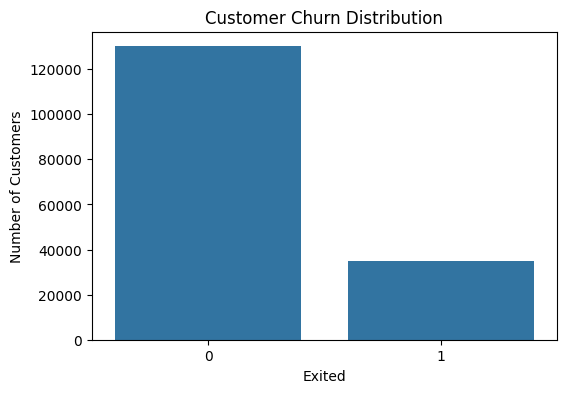

In [5]:

# 3. TARGET DISTRIBUTION


target_counts = train["Exited"].value_counts()
target_percent = train["Exited"].value_counts(normalize=True).mul(100)

print("Target counts:")
display(target_counts)

print("Target percentage:")
display(target_percent.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Exited")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

## 4. Basic EDA

We will inspect:
- numerical variables
- categorical variables
- churn rate across important customer groups

The purpose is not to find every possible pattern. The goal is to understand the data and identify sensible modelling decisions.

In [6]:

# 4. BASIC DATA INFORMATION


print("Numerical columns:")
display(train.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
display(train.select_dtypes(include="object").columns.tolist())

display(train.describe().T)

Numerical columns:


['id',
 'CustomerId',
 'CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']


Categorical columns:


['Surname', 'Geography', 'Gender']

,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48



Churn rate by Geography:


Geography
Germany    37.90
Spain      17.22
France     16.53
Name: Exited, dtype: float64

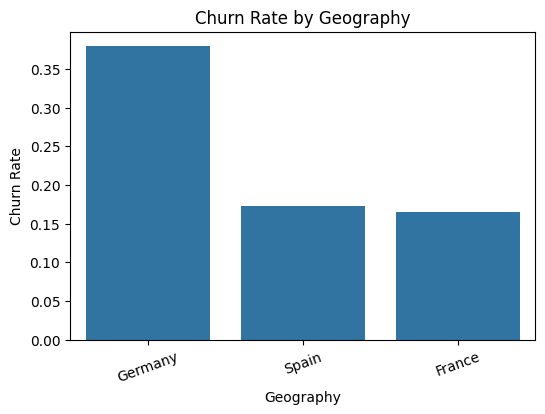


Churn rate by Gender:


Gender
Female    27.97
Male      15.91
Name: Exited, dtype: float64

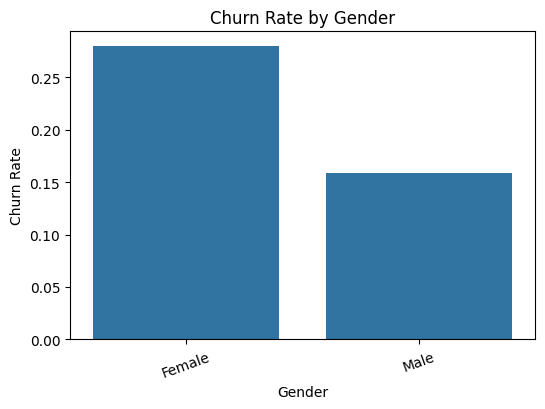


Churn rate by HasCrCard:


HasCrCard
0.0    22.74
1.0    20.64
Name: Exited, dtype: float64

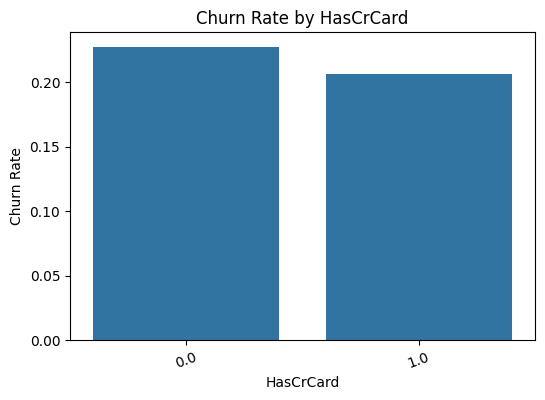


Churn rate by IsActiveMember:


IsActiveMember
0.0    29.71
1.0    12.53
Name: Exited, dtype: float64

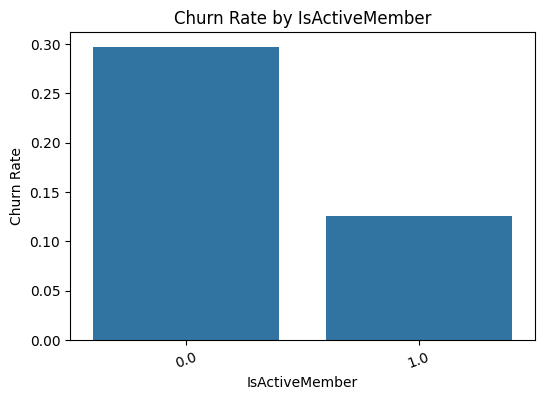

In [7]:
# ============================================================
# 5. CHURN RATE BY IMPORTANT CATEGORICAL FEATURES
# ============================================================

categorical_eda = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

for col in categorical_eda:
    churn_rate = train.groupby(col)["Exited"].mean().sort_values(ascending=False)

    print(f"\nChurn rate by {col}:")
    display((churn_rate * 100).round(2))

    plt.figure(figsize=(6, 4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.xticks(rotation=20)
    plt.show()

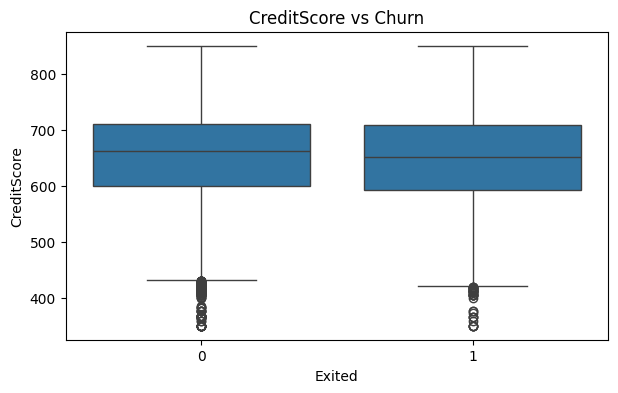

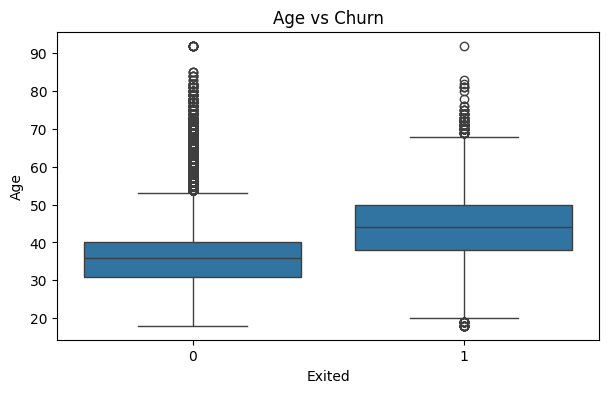

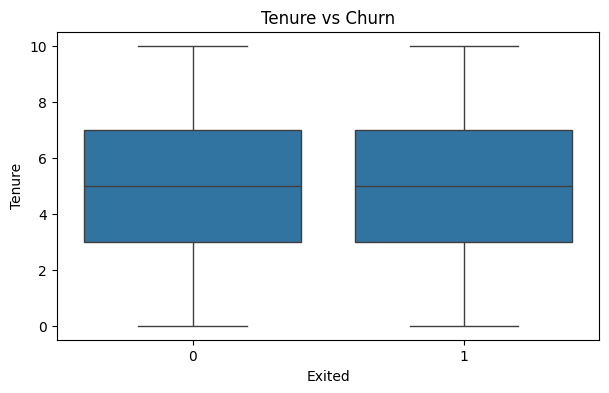

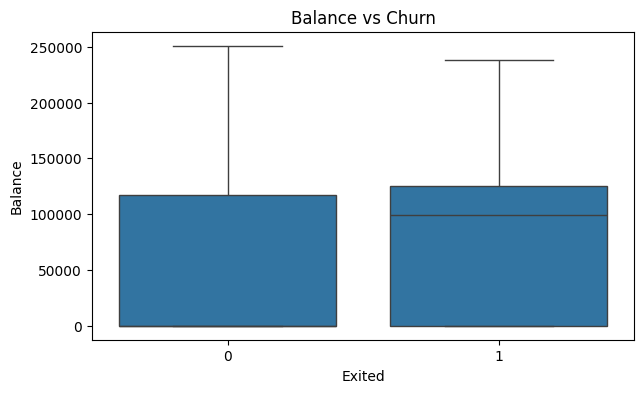

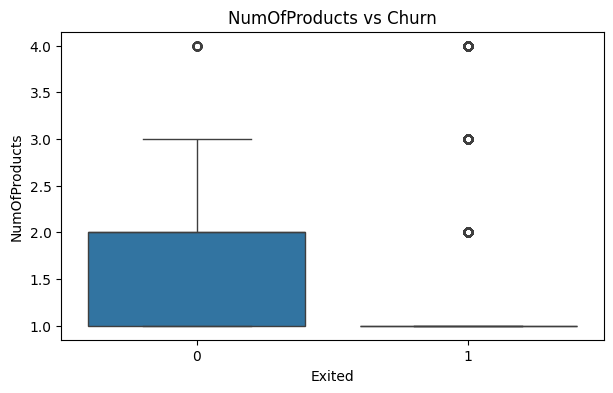

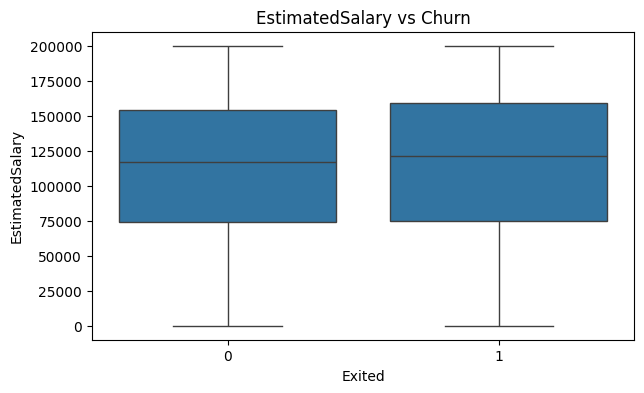

In [8]:

# 6. CHURN RATE BY NUMERICAL VARIABLES


numerical_eda = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for col in numerical_eda:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x="Exited", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

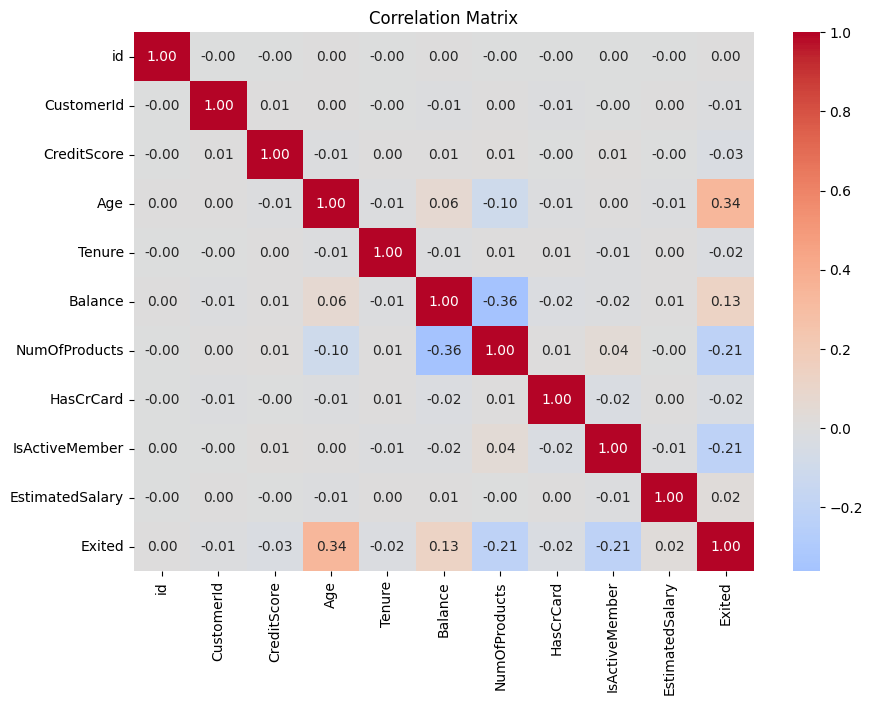

In [9]:
# Correlation among numerical variables
plt.figure(figsize=(10, 7))
corr = train.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## 5. Feature selection

We remove:

- `id` → row/index identifier
- `CustomerId` → customer identifier
- `Surname` → high-cardinality name field

These columns identify customers rather than representing useful general customer behaviour. Keeping identifiers can encourage the model to learn accidental patterns rather than generalizable relationships.

We keep the actual behavioural and demographic variables.

In [10]:

# 7. PREPARE FEATURES AND TARGET


DROP_COLUMNS = ["id", "CustomerId", "Surname"]

X = train.drop(columns=["Exited"] + DROP_COLUMNS)
y = train["Exited"]

print("Training features:", X.shape)

display(X.head())

Training features: (165034, 10)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83


## 6. Train-validation split

We split the training data into:

- **80% training**
- **20% validation**

`stratify=y` keeps approximately the same churn proportion in both sets.

### Important rule

**Fit preprocessing only on the training split.**

This prevents information from the validation set from leaking into the model.

### Role of the validation set

Because the competition test file is not used, this 20% set acts as our **hold-out test set**.

- Hyperparameter tuning uses cross-validation **inside the 80% training portion only**.
- The hold-out set is used to compare the models and to report final performance.
- Because it is also used to *choose between models*, the final score is slightly optimistic.
- Rows from the same `CustomerId` can appear in both sets (see the data integrity check), which can make scores optimistic for brand-new customers.

In [11]:

# 8. TRAIN / VALIDATION SPLIT


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

print("\nChurn rate:")
print("Train     :", round(y_train.mean(), 4))
print("Validation:", round(y_valid.mean(), 4))

X_train: (132027, 10)
X_valid: (33007, 10)

Churn rate:
Train     : 0.2116
Validation: 0.2116


## 7. Preprocessing

There are two types of predictors:

**Numerical**
- CreditScore
- Age
- Tenure
- Balance
- NumOfProducts
- EstimatedSalary
- HasCrCard
- IsActiveMember

**Categorical**
- Geography
- Gender

For Logistic Regression:
- numerical variables are standardized
- categorical variables are one-hot encoded

The preprocessing is placed inside a `Pipeline`, so it is fitted only on the training data.

Tree models do not require scaling, but using a separate preprocessing pipeline keeps the modelling process clean and explicit.

In [12]:

# 9. PREPROCESSING


categorical_features = ["Geography", "Gender"]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_transformer_scaled, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# 8. Model 1 — Logistic Regression

This is our **baseline model**.

Logistic Regression is useful because it is:
- simple
- fast
- interpretable
- a good benchmark for classification

If a complex model does not beat the baseline meaningfully, its extra complexity may not be justified.

In [13]:

# 10. LOGISTIC REGRESSION


logistic_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict_proba(X_valid)[:, 1]

logistic_auc = roc_auc_score(y_valid, logistic_pred)

print(f"Logistic Regression ROC-AUC: {logistic_auc:.5f}")

Logistic Regression ROC-AUC: 0.81449


# 9. Model 2 — Decision Tree

Decision Trees can capture non-linear relationships and interactions automatically.

Unlike Logistic Regression, a tree does **not** need feature scaling.

We restrict the tree depth to reduce overfitting.

In [14]:

# 11. DECISION TREE


tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

tree_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict_proba(X_valid)[:, 1]
tree_auc = roc_auc_score(y_valid, tree_pred)

print(f"Decision Tree ROC-AUC: {tree_auc:.5f}")

Decision Tree ROC-AUC: 0.88016


# 10. Model 3 — Random Forest

Random Forest combines many decision trees.

The idea is to reduce the variance of a single decision tree by averaging predictions from many trees built using randomness.

In [15]:

# 12. RANDOM FOREST


rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict_proba(X_valid)[:, 1]
rf_auc = roc_auc_score(y_valid, rf_pred)

print(f"Random Forest ROC-AUC: {rf_auc:.5f}")

Random Forest ROC-AUC: 0.88681


### Overfitting check: training vs validation ROC-AUC

A model's validation score alone does not show whether it is overfitting.
Comparing it with the **training** score does:

| Pattern | Meaning |
|---|---|
| Train ≈ Validation, both low | **Underfitting** (high bias) - model too simple |
| Train high, Validation much lower | **Overfitting** (high variance) - model memorised training noise |
| Train ≈ Validation, both high | Good generalisation |

**Caveat for Random Forest:** every training row is part of the bootstrap sample of roughly 63% of the trees,
so its training AUC is optimistic by construction. Its gap is therefore not directly comparable with the other models
(the out-of-bag score, `oob_score=True`, is a fairer internal estimate).

In [ ]:
# TRAIN vs VALIDATION ROC-AUC

fitted_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
}

rows = []
for model_name, fitted in fitted_models.items():
    train_auc = roc_auc_score(y_train, fitted.predict_proba(X_train)[:, 1])
    valid_auc = roc_auc_score(y_valid, fitted.predict_proba(X_valid)[:, 1])

    rows.append({
        "Model": model_name,
        "Train AUC": train_auc,
        "Validation AUC": valid_auc,
        "Gap (Train - Valid)": train_auc - valid_auc,
    })

overfitting_check = pd.DataFrame(rows).set_index("Model")
display(overfitting_check.round(4))

# 11. Model 4 — XGBoost

Gradient boosting builds trees **sequentially**.

Each new tree tries to improve the errors made by the previous ensemble.

XGBoost is particularly useful for tabular datasets like this one.

We will use a conservative starting configuration first, then tune it.

In [16]:

# 13. XGBOOST


xgb_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict_proba(X_valid)[:, 1]
xgb_auc = roc_auc_score(y_valid, xgb_pred)

print(f"XGBoost ROC-AUC: {xgb_auc:.5f}")

XGBoost ROC-AUC: 0.88959


# 12. Compare the models

ROC-AUC measures ranking quality:

- **0.5** → roughly random ranking
- **1.0** → perfect separation

We care about the probability predictions, not just the 0/1 class predictions.

In [17]:
# ============================================================
# 14. COMPLETE MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss
)

def evaluate_model(y_true, probabilities, threshold=0.50):
    """
    Evaluate a binary classification model using
    both probability-based and threshold-based metrics.
    """

    predictions = (probabilities >= threshold).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
        "Log Loss": log_loss(y_true, probabilities),
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1-Score": f1_score(y_true, predictions, zero_division=0)
    }


# Predictions from all models
model_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}


# Evaluate every model
evaluation_results = pd.DataFrame({
    model_name: evaluate_model(y_valid, predictions)
    for model_name, predictions in model_predictions.items()
}).T


# Display results
display(evaluation_results.round(4))

,ROC-AUC,PR-AUC,Log Loss,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.8145,0.5800,0.3990,0.8334,0.6933,0.3813,0.4920
Decision Tree,0.8802,0.7014,0.3308,0.8607,0.7172,0.5639,0.6313
Random Forest,0.8868,0.7154,0.3284,0.8621,0.7676,0.4993,0.6050
XGBoost,0.8896,0.7296,0.3195,0.8658,0.7448,0.5561,0.6368


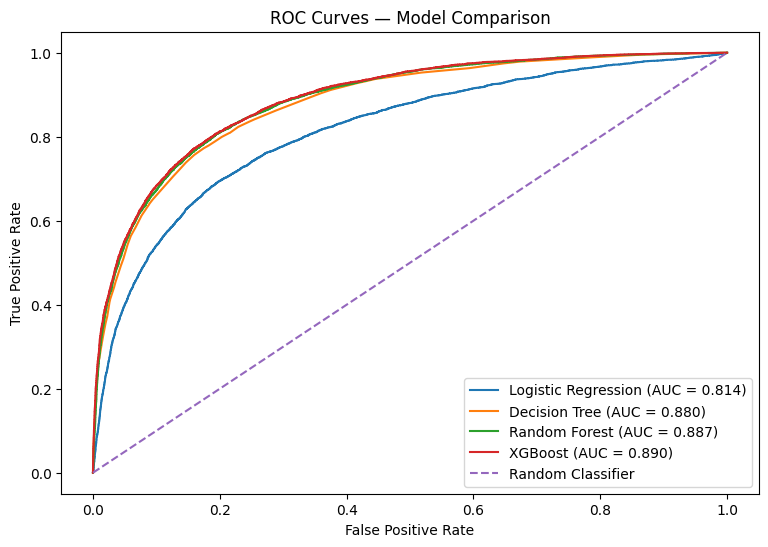

In [18]:

# 15. ROC CURVES


plt.figure(figsize=(9, 6))

for model_name, predictions in model_predictions.items():

    fpr, tpr, _ = roc_curve(y_valid, predictions)
    auc = roc_auc_score(y_valid, predictions)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

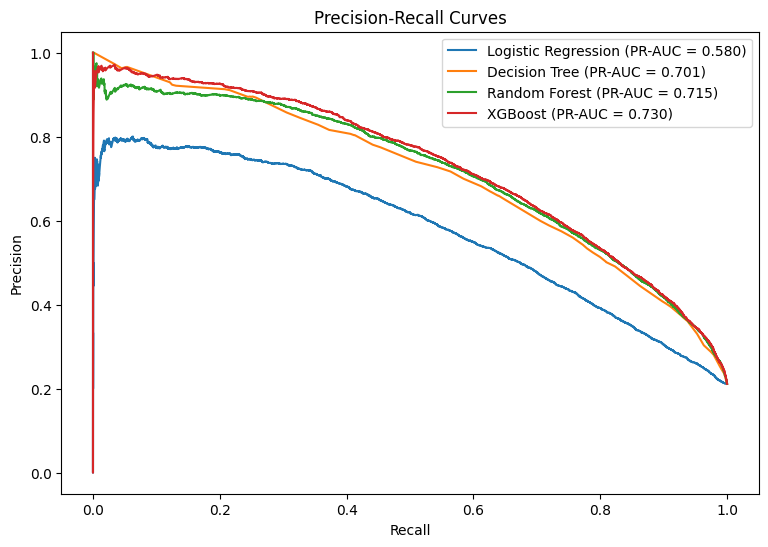

In [19]:
# ============================================================
# 16. PRECISION-RECALL CURVES
# ============================================================

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(9, 6))

for model_name, predictions in model_predictions.items():

    precision, recall, _ = precision_recall_curve(
        y_valid,
        predictions
    )

    pr_auc = average_precision_score(
        y_valid,
        predictions
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

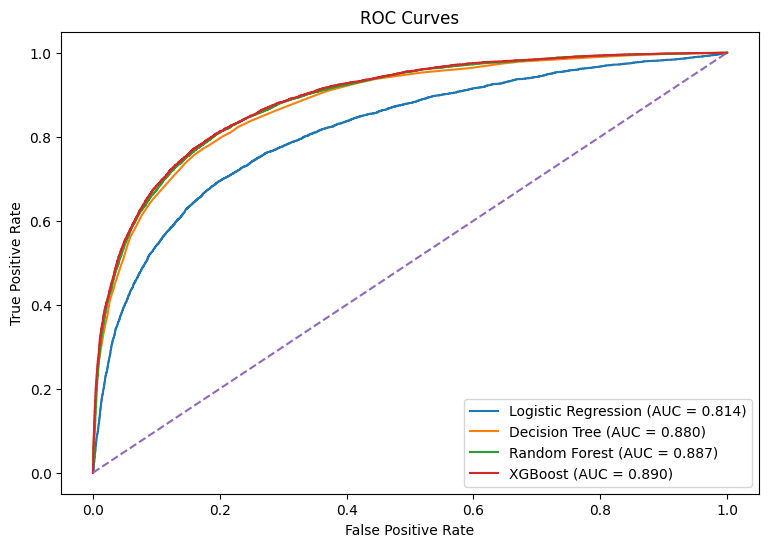

In [20]:
# ROC curves

models_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

plt.figure(figsize=(9, 6))

for name, pred in models_predictions.items():
    fpr, tpr, _ = roc_curve(y_valid, pred)
    auc = roc_auc_score(y_valid, pred)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# 13. Hyperparameter tuning — XGBoost

The main parameters we will explore are:

- `n_estimators` → number of boosting trees
- `learning_rate` → contribution of each tree
- `max_depth` → tree complexity
- `min_child_weight` → minimum amount of data needed for a split
- `subsample` → fraction of rows used per tree
- `colsample_bytree` → fraction of features used per tree

We optimize **ROC-AUC**, because it is the project's evaluation metric (ranking quality across all thresholds).

In [21]:

# 15. XGBOOST HYPERPARAMETER TUNING


xgb_pipeline_for_tuning = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

param_distributions = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.10],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline_for_tuning,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best ROC-AUC from CV:", random_search.best_score_)
print("\nBest parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best ROC-AUC from CV: 0.8891678787485519

Best parameters:
{'model__subsample': 0.8, 'model__n_estimators': 700, 'model__min_child_weight': 10, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}


In [26]:

# 16. VALIDATION PERFORMANCE OF TUNED MODEL


tuned_xgb = random_search.best_estimator_

tuned_pred = tuned_xgb.predict_proba(X_valid)[:, 1]
tuned_auc = roc_auc_score(y_valid, tuned_pred)

print(f"Tuned XGBoost validation ROC-AUC: {tuned_auc:.5f}")

Tuned XGBoost validation ROC-AUC: 0.89047


In [27]:
# ============================================================
# 18. FINAL MODEL COMPARISON
# ============================================================

final_model_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Tuned XGBoost": tuned_pred
}

final_evaluation = pd.DataFrame({
    model_name: evaluate_model(y_valid, predictions)
    for model_name, predictions in final_model_predictions.items()
}).T

display(final_evaluation.round(4))

,ROC-AUC,PR-AUC,Log Loss,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.8145,0.5800,0.3990,0.8334,0.6933,0.3813,0.4920
Decision Tree,0.8802,0.7014,0.3308,0.8607,0.7172,0.5639,0.6313
Random Forest,0.8868,0.7154,0.3284,0.8621,0.7676,0.4993,0.6050
XGBoost,0.8896,0.7296,0.3195,0.8658,0.7448,0.5561,0.6368
Tuned XGBoost,0.8905,0.7308,0.3185,0.8655,0.7467,0.5515,0.6344


# 14. Feature importance

Feature importance helps answer an interview question:

> "Which variables were most useful for predicting churn?"

For XGBoost, we can inspect the importance values after preprocessing.

Because categorical variables are one-hot encoded, categories such as `Geography_France` and `Gender_Male` appear as separate transformed features.

In [28]:

# 17. FEATURE IMPORTANCE


# Fit the tuned model's preprocessing separately so that
# we can recover the transformed feature names.

fitted_preprocessor = tuned_xgb.named_steps["preprocessor"]
fitted_xgb = tuned_xgb.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

,Feature,Importance
4,num__NumOfProducts,0.345132
6,num__IsActiveMember,0.191894
1,num__Age,0.187501
9,cat__Geography_Germany,0.105540
11,cat__Gender_Female,0.085569
3,num__Balance,0.037078
5,num__HasCrCard,0.013085
0,num__CreditScore,0.007411
2,num__Tenure,0.007181
7,num__EstimatedSalary,0.007066


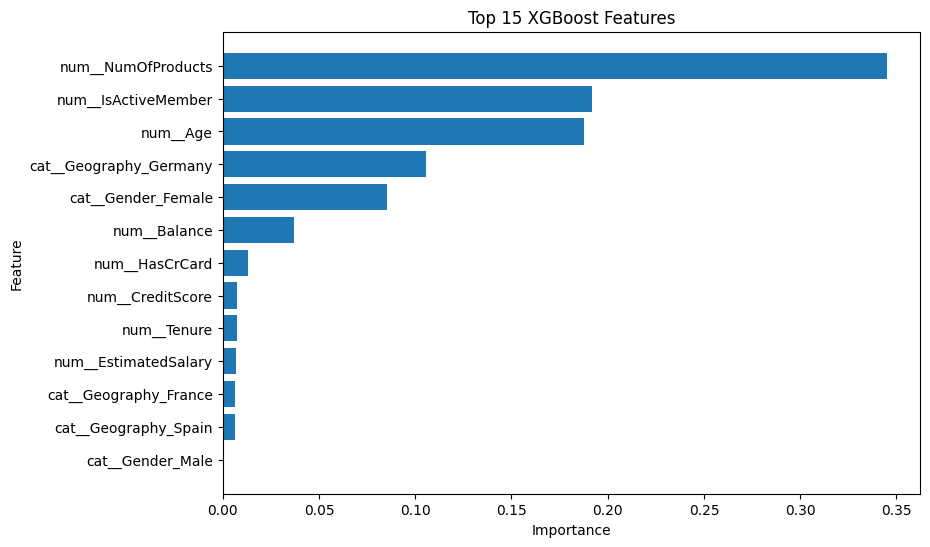

In [29]:
plt.figure(figsize=(9, 6))

top_features = feature_importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")
plt.show()

# 15. Threshold and confusion matrix

ROC-AUC evaluates the ranking of predicted probabilities.

For an actual business decision, however, we eventually need a threshold to convert probabilities into classes.

The default threshold is usually **0.50**, but it is not automatically the best business threshold.

In this project, ROC-AUC (threshold-free) is the main metric. The 0.50 threshold below is only for illustration; a real bank would choose the threshold from the business costs of missed churners versus wasted retention offers.

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     26023
           1       0.75      0.55      0.63      6984

    accuracy                           0.87     33007
   macro avg       0.82      0.75      0.78     33007
weighted avg       0.86      0.87      0.86     33007



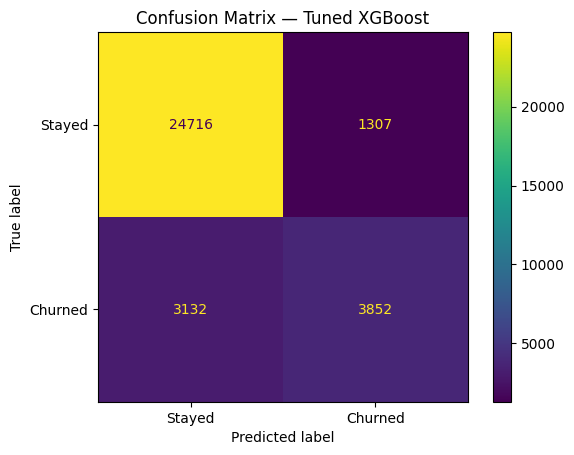

In [30]:

# 18. CLASSIFICATION REPORT AT 0.50 THRESHOLD


final_valid_pred = (tuned_pred >= 0.50).astype(int)

print(classification_report(y_valid, final_valid_pred))

cm = confusion_matrix(y_valid, final_valid_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Confusion Matrix — Tuned XGBoost")
plt.show()

# 16. Final model

The final performance of the selected model is its ROC-AUC, classification report and confusion matrix on the **hold-out set** (previous cells).

In a real deployment, we would retrain the chosen configuration on **all** labelled data before serving predictions. We skip that here, because no unseen labelled data would remain to evaluate the retrained model.

# 18. Final project summary

### What we did

**1. Data understanding**
- inspected dimensions, types, missing values and duplicates
- checked target imbalance

**2. EDA**
- studied churn rates across categorical variables
- inspected numerical variables
- checked correlations

**3. Preprocessing**
- removed customer identifiers
- one-hot encoded categorical variables
- standardized numerical variables for Logistic Regression
- kept preprocessing inside pipelines to prevent leakage

**4. Models**
- Logistic Regression → baseline
- Decision Tree → non-linear model
- Random Forest → bagging ensemble
- XGBoost → gradient boosting

**5. Evaluation**
- used ROC-AUC as the main metric (ranking quality across all thresholds)
- compared ROC curves
- examined the confusion matrix at a 0.50 threshold

**6. Tuning**
- tuned XGBoost using cross-validation and ROC-AUC

**7. Final evaluation**
- split `train.csv` once into a training set and a stratified hold-out set
- scored the selected model on the hold-out set (ROC-AUC, classification report, confusion matrix)
- inspected feature importance

### Interview takeaway

The important story is not:

> "I used XGBoost and got a good score."

A much stronger explanation is:

> "I first established a Logistic Regression baseline, then compared progressively more flexible tree-based models using ROC-AUC. I used pipelines to keep preprocessing inside the training process and avoid data leakage. After comparing the models, I tuned the boosting model with cross-validation and finally evaluated it on a stratified hold-out set that was not used for tuning."

## Interview questions you should be ready for

1. Why is ROC-AUC used instead of accuracy?
2. Why did you remove `CustomerId` and `Surname`?
3. Why do we split before fitting the scaler/encoder?
4. Why does Logistic Regression need scaling while a Decision Tree does not?
5. What is the difference between Bagging and Boosting?
6. What does `learning_rate` do in XGBoost?
7. What happens when `max_depth` becomes too large?
8. Why can training ROC-AUC be high while validation ROC-AUC is lower?
9. Why do we use `predict_proba()` for this project?
10. What is data leakage?
11. What is the difference between ROC-AUC and accuracy?
12. Why can a tuned model sometimes perform worse on the validation set than an earlier model?
13. How would you choose a churn threshold in a real bank?
14. Which features are most important and how would you explain them to a non-technical stakeholder?